# Análisis Estadístico de Ficheros CODIESP

Este notebook realiza un análisis estadístico detallado del conjunto de datos CODIESP, que contiene textos clínicos en español con sus correspondientes códigos CIE-10-ES.

## 1. Importar Bibliotecas Necesarias

En esta sección importamos todas las bibliotecas necesarias para realizar el análisis estadístico de los datos de CODIESP.

In [10]:
# Importar bibliotecas para análisis de datos
import pandas as pd
import numpy as np
import ast  # Para evaluar strings como listas
import re

# Bibliotecas para visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Procesamiento de lenguaje natural
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

# Configuraciones de visualización
plt.style.use('ggplot')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Para guardar archivos Markdown
import os
import json
from IPython.display import display, Markdown

# Descarga de recursos NLTK necesarios
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    spanish_stopwords = set(stopwords.words('spanish'))
except:
    print("No se pudieron descargar los recursos de NLTK. Se usará una lista vacía de stopwords.")
    spanish_stopwords = set()

## 2. Cargar y Explorar los Datos CODIESP

En esta sección cargaremos los datos de CODIESP y realizaremos una exploración inicial para comprender su estructura.

In [11]:
# Definir rutas de los archivos CSV de CODIESP
ruta_base = '/Users/david/own/CIE-10/'
ruta_codiesp = os.path.join(ruta_base, 'csv_import_scripts/codiesp_csvs')

# Archivos CODIESP
archivos_codiesp = {
    'train': os.path.join(ruta_codiesp, 'codiesp_D_source_train.csv'),
    'test': os.path.join(ruta_codiesp, 'codiesp_D_source_test.csv'),
    'validation': os.path.join(ruta_codiesp, 'codiesp_D_source_validation.csv')
}

print("Rutas de archivos CODIESP:")
for tipo, ruta in archivos_codiesp.items():
    print(f"- {tipo}: {ruta}")

# Cargar los datos de CODIESP
dfs_codiesp = {}
try:
    print("\nCargando archivos CODIESP...")
    for tipo, ruta in archivos_codiesp.items():
        dfs_codiesp[tipo] = pd.read_csv(ruta)
        print(f"Archivo {tipo} cargado: {dfs_codiesp[tipo].shape[0]} registros, {dfs_codiesp[tipo].shape[1]} columnas")

    print("\nTodos los archivos cargados correctamente.")
except Exception as e:
    print(f"Error al cargar los archivos: {str(e)}")

Rutas de archivos CODIESP:
- train: /Users/david/own/CIE-10/csv_import_scripts/codiesp_csvs/codiesp_D_source_train.csv
- test: /Users/david/own/CIE-10/csv_import_scripts/codiesp_csvs/codiesp_D_source_test.csv
- validation: /Users/david/own/CIE-10/csv_import_scripts/codiesp_csvs/codiesp_D_source_validation.csv

Cargando archivos CODIESP...
Archivo train cargado: 500 registros, 2 columnas
Archivo test cargado: 250 registros, 2 columnas
Archivo validation cargado: 250 registros, 2 columnas

Todos los archivos cargados correctamente.



Exploración del conjunto train

Dimensiones: 500 registros, 2 columnas

Primeras 2 filas:


,text,labels
0,Describimos el caso de un varón de 37 años con...,n44.8;z20.818;r60.9;r52;a23.9;i83.90;i87.8;r50...
1,Se trata de una mujer de 29 años sometida a un...,d30.3;r58



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    500 non-null    object
 1   labels  500 non-null    object
dtypes: object(2)
memory usage: 7.9+ KB


None


Verificar valores nulos:


text      0
labels    0
dtype: int64


Análisis de la columna 'labels':
Total de etiquetas: 5639
Etiquetas únicas: 1767

Estadísticas del número de etiquetas por documento:


count    500.0000
mean      11.2780
std        6.9453
min        1.0000
25%        6.0000
50%       10.0000
75%       15.0000
max       40.0000
Name: num_etiquetas, dtype: float64


Las 10 etiquetas más comunes:
- r52: 112 ocurrencias
- r69: 99 ocurrencias
- r50.9: 97 ocurrencias
- i10: 77 ocurrencias
- r60.9: 66 ocurrencias
- r59.9: 65 ocurrencias
- r53.1: 57 ocurrencias
- r11.10: 47 ocurrencias
- r59.0: 46 ocurrencias
- r10.9: 46 ocurrencias


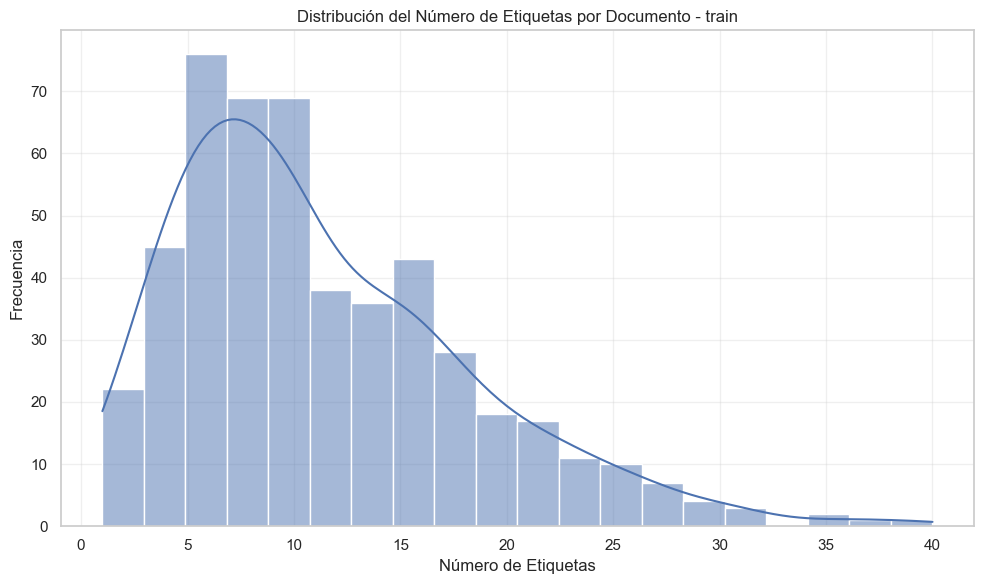


Exploración del conjunto test

Dimensiones: 250 registros, 2 columnas

Primeras 2 filas:


,text,labels
0,"Paciente de 70 años de edad, minero jubilado, ...",s22.49xa;n28.1;r69;f17.210;r31.9;f17.200;r31.2...
1,Varón de diecisiete años sin antecedentes de i...,n32.9;r30.0;r31.9;d30.3;r35.0;i96



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    250 non-null    object
 1   labels  250 non-null    object
dtypes: object(2)
memory usage: 4.0+ KB


None


Verificar valores nulos:


text      0
labels    0
dtype: int64


Análisis de la columna 'labels':
Total de etiquetas: 2842
Etiquetas únicas: 1143

Estadísticas del número de etiquetas por documento:


count    250.000000
mean      11.368000
std        6.593822
min        1.000000
25%        6.000000
50%       10.000000
75%       15.000000
max       35.000000
Name: num_etiquetas, dtype: float64


Las 10 etiquetas más comunes:
- r52: 56 ocurrencias
- r50.9: 49 ocurrencias
- r69: 48 ocurrencias
- i10: 45 ocurrencias
- r59.9: 41 ocurrencias
- r60.9: 33 ocurrencias
- r58: 28 ocurrencias
- r10.9: 28 ocurrencias
- r59.0: 27 ocurrencias
- e11.9: 25 ocurrencias


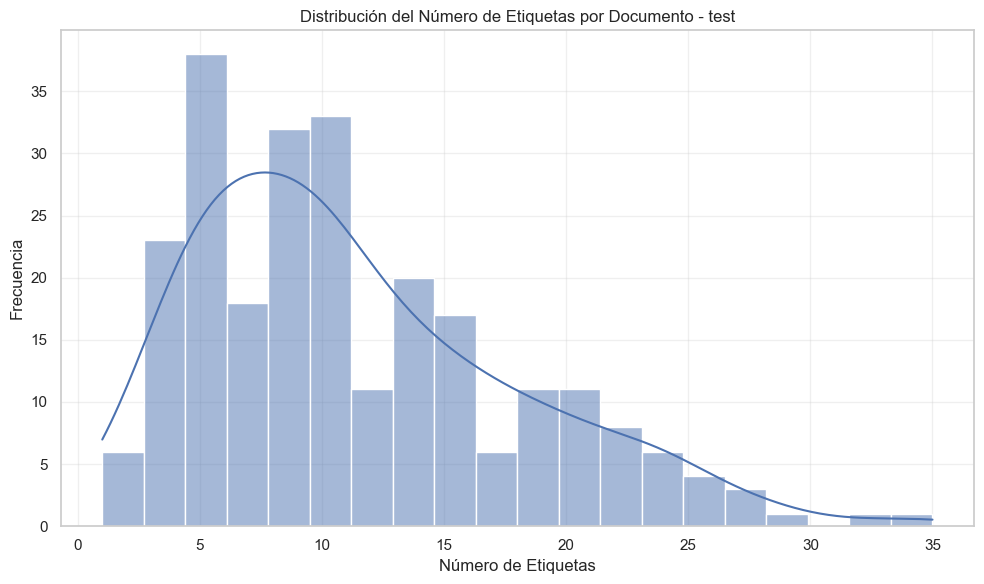


Exploración del conjunto validation

Dimensiones: 250 registros, 2 columnas

Primeras 2 filas:


,text,labels
0,Mujer de 29 años con antecedentes de ulcus duo...,q62.11;n28.89;n39.0;r31.9;n23;n28.0;d18.09;n13...
1,Varón de 58 años de edad en el momento del tra...,t86.11;i25.10;n02.8;r25.1;n05.1;q53.20;i10;n21...



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    250 non-null    object
 1   labels  250 non-null    object
dtypes: object(2)
memory usage: 4.0+ KB


None


Verificar valores nulos:


text      0
labels    0
dtype: int64


Análisis de la columna 'labels':
Total de etiquetas: 2677
Etiquetas únicas: 1158

Estadísticas del número de etiquetas por documento:


count    250.000000
mean      10.708000
std        6.805291
min        1.000000
25%        5.000000
50%       10.000000
75%       14.000000
max       33.000000
Name: num_etiquetas, dtype: float64


Las 10 etiquetas más comunes:
- r69: 51 ocurrencias
- r52: 51 ocurrencias
- r50.9: 45 ocurrencias
- i10: 39 ocurrencias
- r59.9: 30 ocurrencias
- r11.10: 27 ocurrencias
- b99.9: 25 ocurrencias
- r60.9: 25 ocurrencias
- e11.9: 19 ocurrencias
- r59.0: 18 ocurrencias


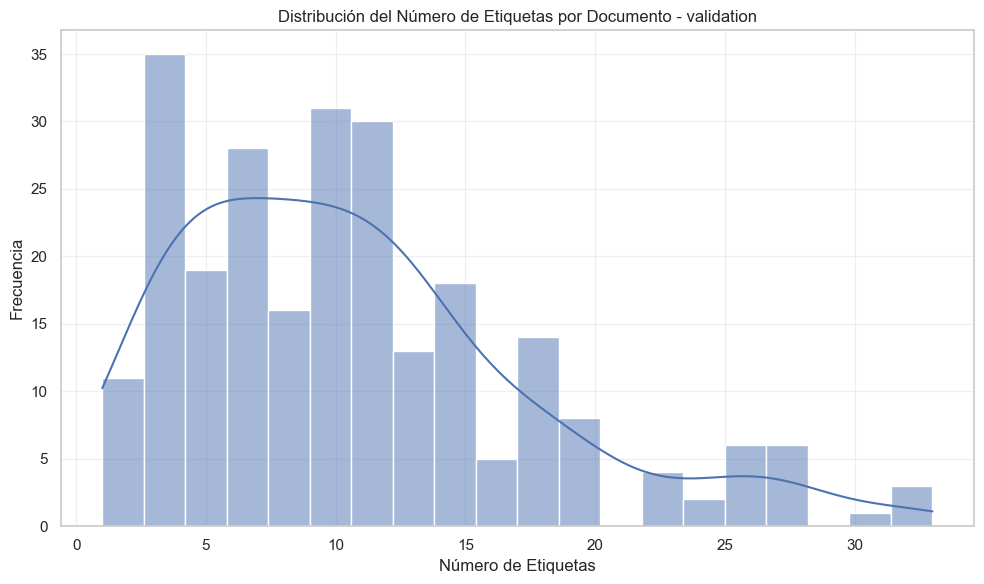

In [12]:
# Función para explorar la estructura de los datos CODIESP
def explorar_estructura_codiesp(nombre_conjunto, df):
    print(f"\n{'='*50}")
    print(f"Exploración del conjunto {nombre_conjunto}")
    print(f"{'='*50}")

    print(f"\nDimensiones: {df.shape[0]} registros, {df.shape[1]} columnas")

    print("\nPrimeras 2 filas:")
    display(df.head(2))

    print("\nInformación del DataFrame:")
    display(df.info())

    print("\nVerificar valores nulos:")
    display(df.isnull().sum())

    # Explorar la columna de etiquetas
    if 'labels' in df.columns:
        print("\nAnálisis de la columna 'labels':")

        # Función para extraer etiquetas de la representación de string de lista
        def extraer_etiquetas(labels_str):
            try:
                return labels_str.split(';')
            except:
                return []

        # Extraer todas las etiquetas
        todas_etiquetas = []
        for labels_str in df['labels']:
            etiquetas = extraer_etiquetas(labels_str)
            todas_etiquetas.extend(etiquetas)

        print(f"Total de etiquetas: {len(todas_etiquetas)}")
        print(f"Etiquetas únicas: {len(set(todas_etiquetas))}")

        # Número de etiquetas por documento
        df['num_etiquetas'] = df['labels'].apply(lambda x: len(extraer_etiquetas(x)))

        print("\nEstadísticas del número de etiquetas por documento:")
        display(df['num_etiquetas'].describe())

        # Las 10 etiquetas más comunes
        top_10_etiquetas = Counter(todas_etiquetas).most_common(10)
        print("\nLas 10 etiquetas más comunes:")
        for etiqueta, count in top_10_etiquetas:
            print(f"- {etiqueta}: {count} ocurrencias")

        # Visualización del número de etiquetas por documento
        plt.figure(figsize=(10, 6))
        sns.histplot(df['num_etiquetas'], kde=True, bins=20)
        plt.title(f'Distribución del Número de Etiquetas por Documento - {nombre_conjunto}')
        plt.xlabel('Número de Etiquetas')
        plt.ylabel('Frecuencia')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        return todas_etiquetas, top_10_etiquetas
    else:
        print("No se encontró la columna 'labels' en este DataFrame.")
        return None, None

# Explorar la estructura de cada conjunto de datos
etiquetas_por_conjunto = {}
top_etiquetas_por_conjunto = {}

for nombre, df in dfs_codiesp.items():
    etiquetas, top_etiquetas = explorar_estructura_codiesp(nombre, df)
    if etiquetas:
        etiquetas_por_conjunto[nombre] = etiquetas
        top_etiquetas_por_conjunto[nombre] = top_etiquetas

## 3. Análisis Estadístico Descriptivo

En esta sección realizaremos un análisis estadístico descriptivo de los textos clínicos y las etiquetas.


Análisis Descriptivo de Textos - train

Estadísticas de longitud de textos:


,longitud_texto,num_palabras,num_frases
count,500.000000,500.000000,500.000000
mean,2317.246000,349.018000,17.620000
std,1097.438919,164.745999,8.625799
min,556.000000,73.000000,3.000000
25%,1516.750000,224.750000,11.000000
50%,2100.500000,314.500000,16.000000
75%,2885.250000,435.250000,22.000000
max,7466.000000,1172.000000,54.000000


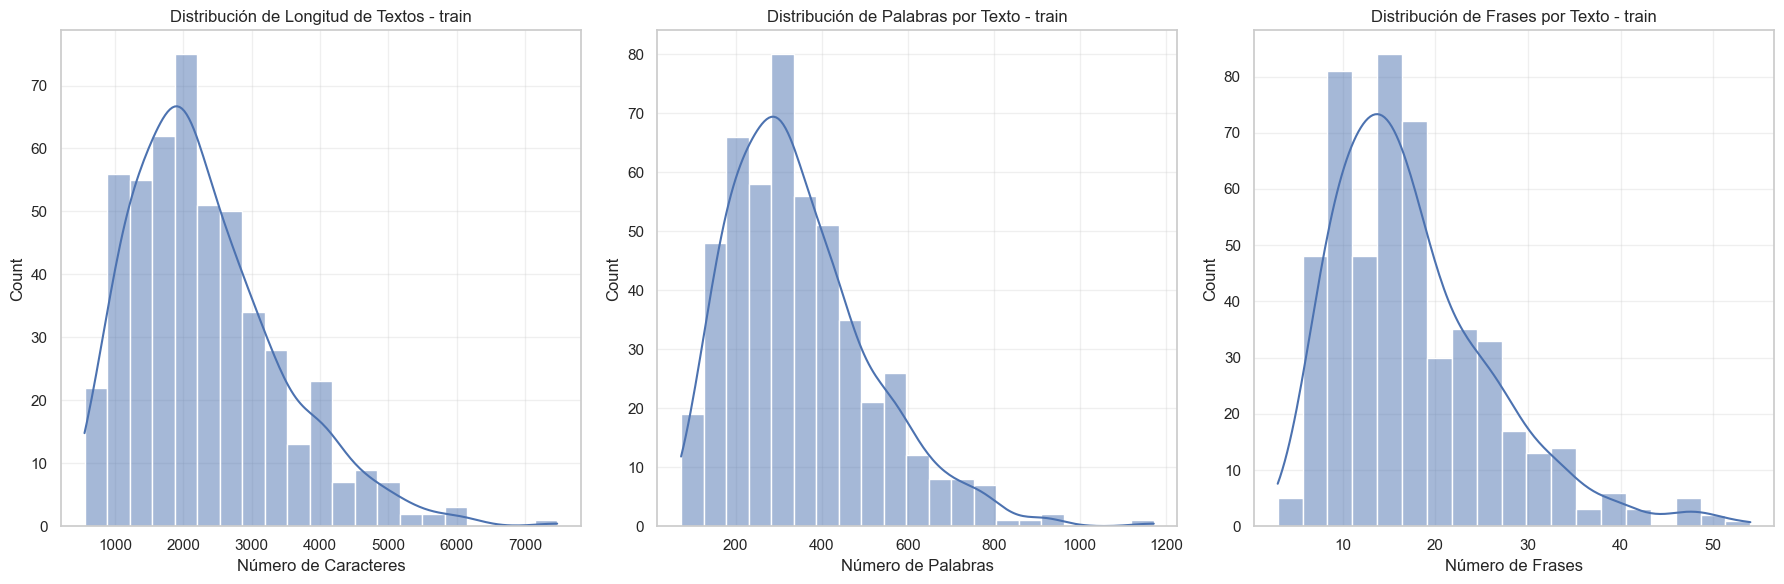


Análisis de palabras más frecuentes:

20 palabras más comunes (excluyendo stopwords):
- paciente: 1201
- tratamiento: 821
- años: 711
- meses: 461
- tras: 425
- estudio: 406
- días: 391
- realizó: 386
- exploración: 377
- normal: 375
- derecho: 362
- dolor: 355
- izquierdo: 354
- antecedentes: 335
- cm: 335
- diagnóstico: 323
- evolución: 305
- lesión: 290
- renal: 283
- servicio: 262


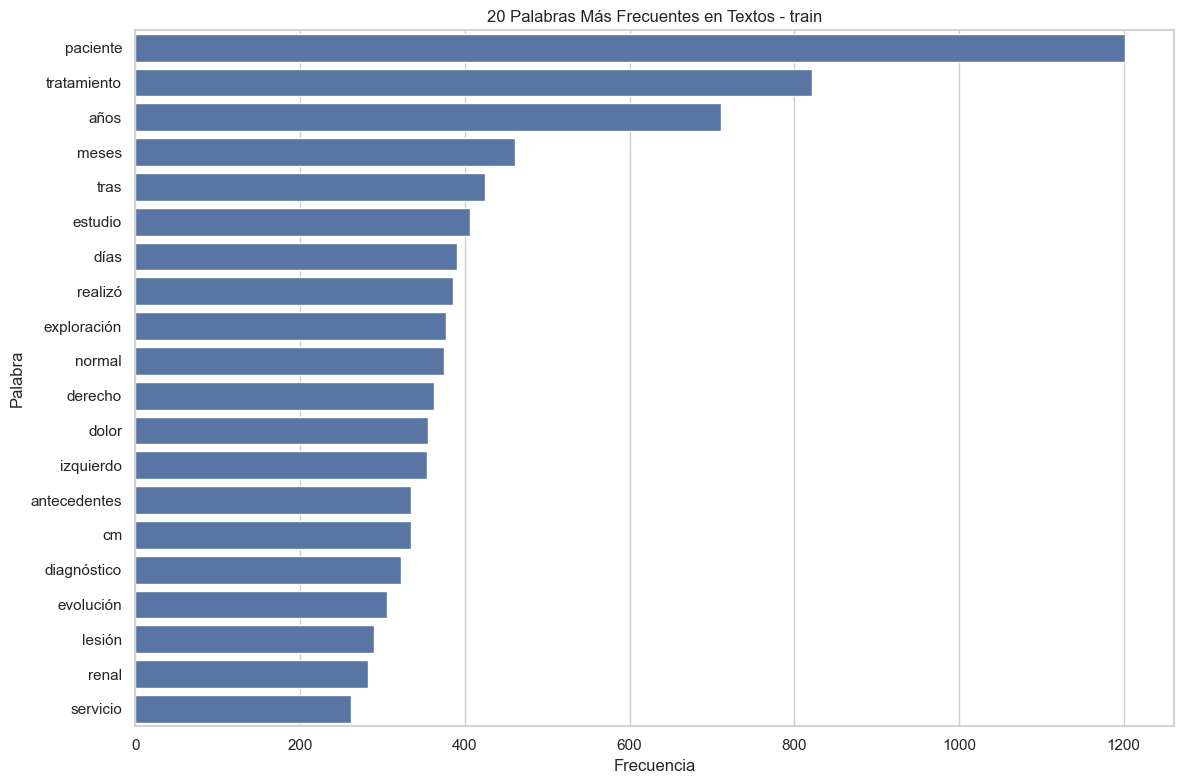


Análisis Descriptivo de Textos - test

Estadísticas de longitud de textos:


,longitud_texto,num_palabras,num_frases
count,250.000000,250.000000,250.000000
mean,2359.436000,352.712000,17.984000
std,1111.034656,163.390523,9.007791
min,555.000000,90.000000,5.000000
25%,1546.500000,235.500000,12.000000
50%,2209.000000,330.500000,16.000000
75%,2962.000000,442.750000,22.000000
max,6526.000000,965.000000,64.000000


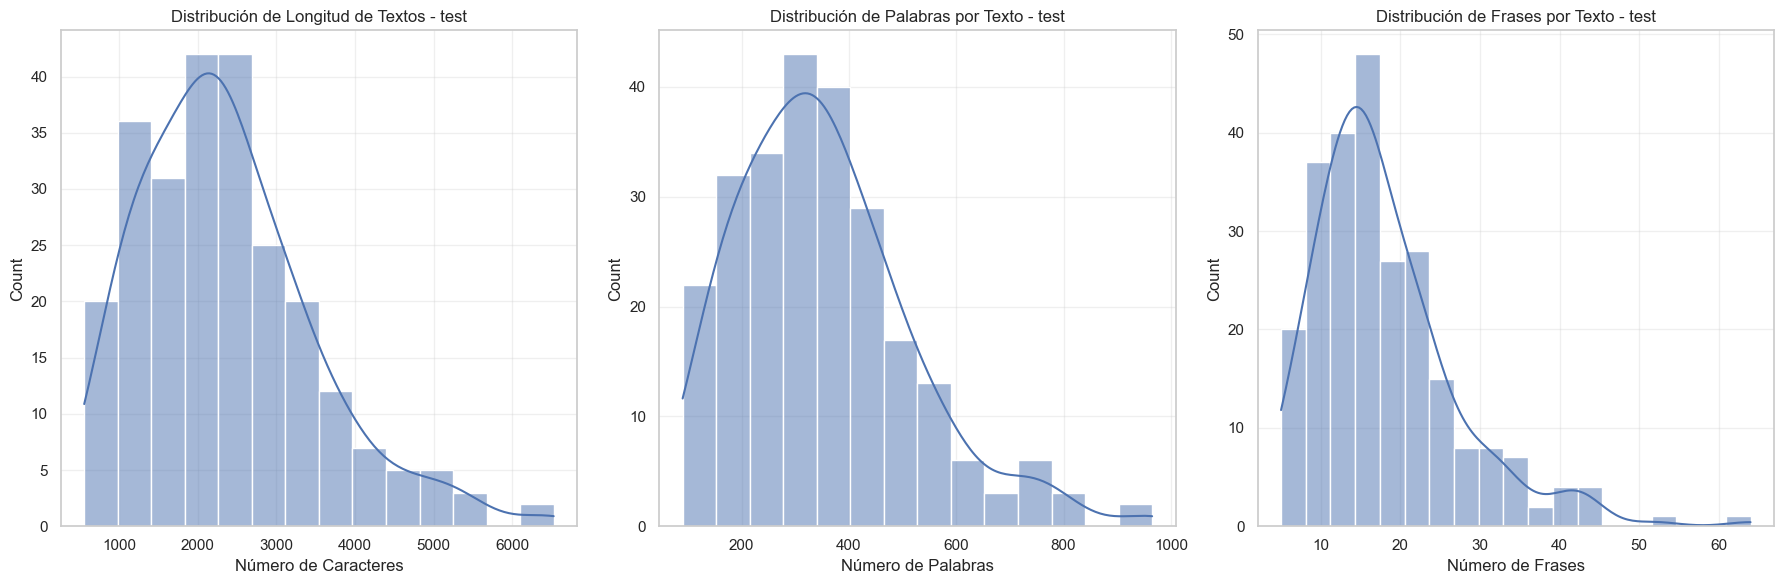


Análisis de palabras más frecuentes:

20 palabras más comunes (excluyendo stopwords):
- paciente: 592
- tratamiento: 396
- años: 368
- tras: 251
- meses: 222
- derecho: 208
- días: 197
- exploración: 195
- realizó: 188
- renal: 185
- estudio: 184
- dolor: 175
- normal: 172
- izquierdo: 167
- evolución: 166
- diagnóstico: 166
- derecha: 164
- cm: 164
- nivel: 157
- antecedentes: 151


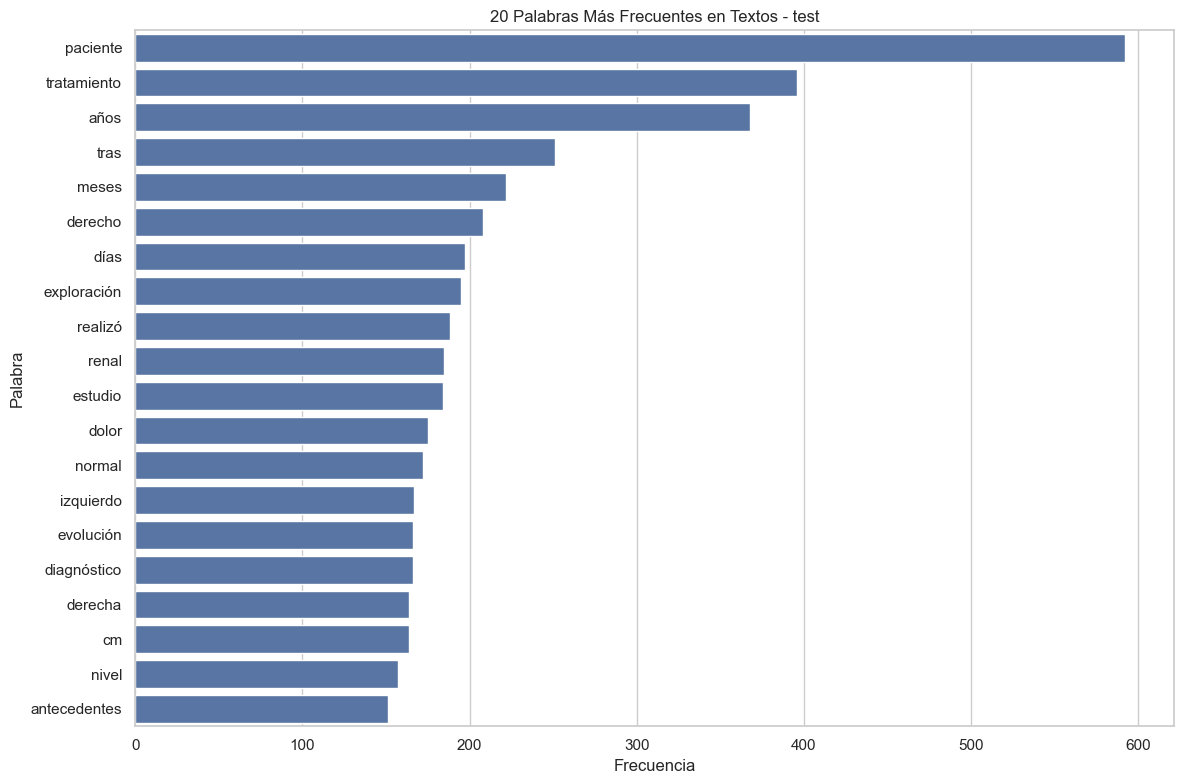


Análisis Descriptivo de Textos - validation

Estadísticas de longitud de textos:


,longitud_texto,num_palabras,num_frases
count,250.000000,250.000000,250.000000
mean,2353.984000,352.296000,18.448000
std,1116.832519,168.171982,9.127791
min,498.000000,69.000000,5.000000
25%,1526.500000,225.250000,12.000000
50%,2220.000000,327.500000,17.000000
75%,2910.000000,429.500000,23.000000
max,6010.000000,956.000000,66.000000


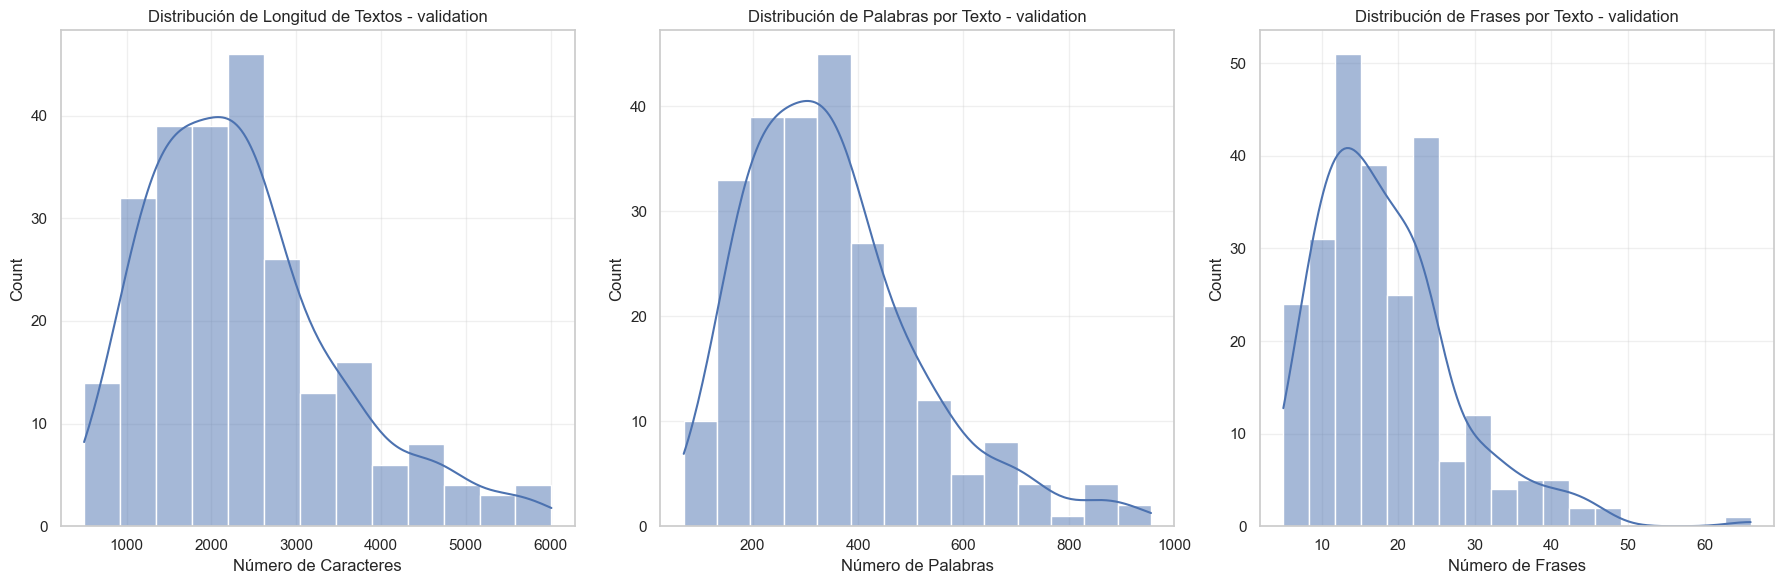


Análisis de palabras más frecuentes:

20 palabras más comunes (excluyendo stopwords):
- paciente: 597
- años: 379
- tratamiento: 371
- tras: 240
- meses: 231
- izquierdo: 210
- estudio: 210
- lesión: 204
- derecho: 199
- cm: 185
- exploración: 180
- realizó: 177
- antecedentes: 171
- evolución: 165
- días: 156
- diagnóstico: 154
- dolor: 153
- normal: 148
- derecha: 142
- renal: 131


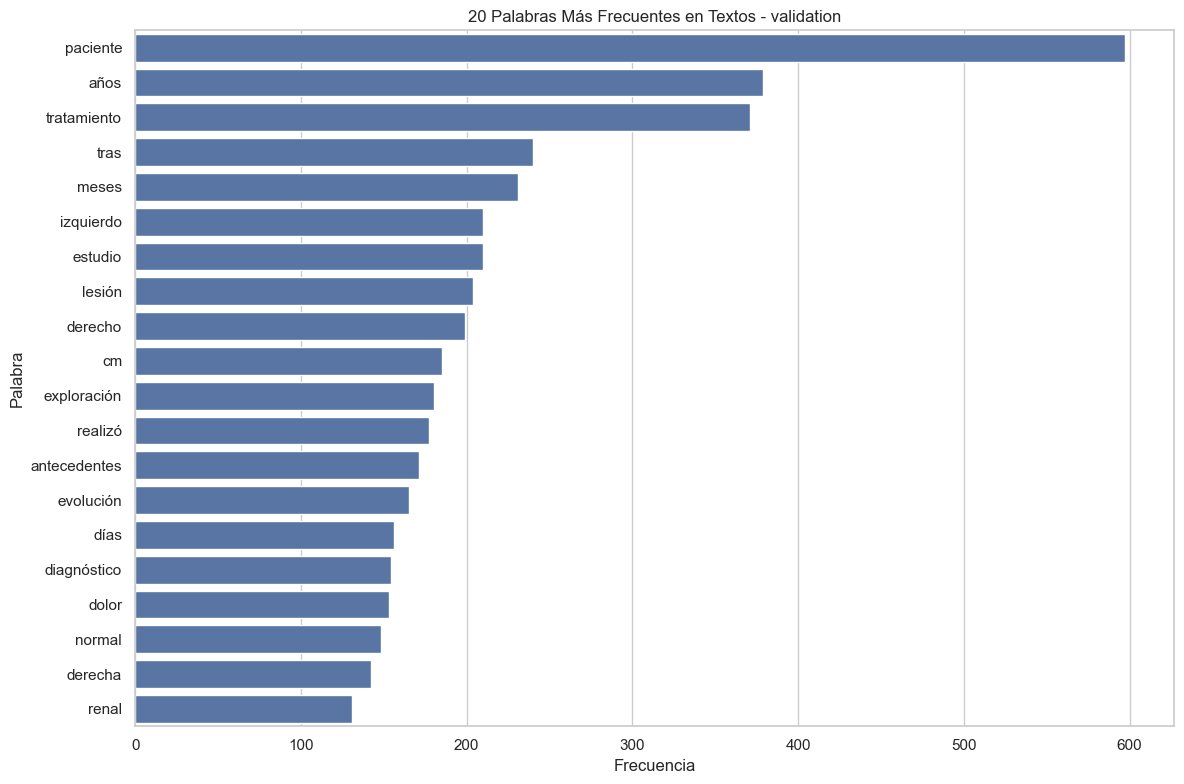

In [13]:
# Análisis descriptivo de los textos clínicos
def analisis_descriptivo_textos(nombre_conjunto, df):
    print(f"\n{'='*50}")
    print(f"Análisis Descriptivo de Textos - {nombre_conjunto}")
    print(f"{'='*50}")

    if 'text' in df.columns:
        # Longitud de los textos
        df['longitud_texto'] = df['text'].apply(len)
        df['num_palabras'] = df['text'].apply(lambda x: len(x.split()))
        df['num_frases'] = df['text'].apply(lambda x: len(re.split(r'[.!?]', x)))

        # Estadísticas básicas
        print("\nEstadísticas de longitud de textos:")
        display(df[['longitud_texto', 'num_palabras', 'num_frases']].describe())

        # Visualizar distribución de longitudes
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        # Longitud de caracteres
        sns.histplot(df['longitud_texto'], kde=True, ax=axes[0])
        axes[0].set_title(f'Distribución de Longitud de Textos - {nombre_conjunto}')
        axes[0].set_xlabel('Número de Caracteres')

        # Número de palabras
        sns.histplot(df['num_palabras'], kde=True, ax=axes[1])
        axes[1].set_title(f'Distribución de Palabras por Texto - {nombre_conjunto}')
        axes[1].set_xlabel('Número de Palabras')

        # Número de frases
        sns.histplot(df['num_frases'], kde=True, ax=axes[2])
        axes[2].set_title(f'Distribución de Frases por Texto - {nombre_conjunto}')
        axes[2].set_xlabel('Número de Frases')

        for ax in axes:
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Análisis de palabras más comunes
        print("\nAnálisis de palabras más frecuentes:")

        # Tokenizar y filtrar stopwords
        todas_palabras = []
        for texto in df['text']:
            try:
                palabras = [word.lower() for word in word_tokenize(texto, language='spanish')
                            if word.isalpha() and word.lower() not in spanish_stopwords]
                todas_palabras.extend(palabras)
            except:
                continue

        # Mostrar palabras más comunes
        palabras_comunes = Counter(todas_palabras).most_common(20)
        print("\n20 palabras más comunes (excluyendo stopwords):")
        for palabra, freq in palabras_comunes:
            print(f"- {palabra}: {freq}")

        # Visualizar palabras más comunes
        plt.figure(figsize=(12, 8))
        palabras_df = pd.DataFrame(palabras_comunes, columns=['Palabra', 'Frecuencia'])
        sns.barplot(x='Frecuencia', y='Palabra', data=palabras_df)
        plt.title(f'20 Palabras Más Frecuentes en Textos - {nombre_conjunto}')
        plt.tight_layout()
        plt.show()

        return df[['longitud_texto', 'num_palabras', 'num_frases']], palabras_comunes
    else:
        print("No se encontró la columna 'text' en este DataFrame.")
        return None, None

# Ejecutar análisis descriptivo para cada conjunto
estadisticas_texto_por_conjunto = {}
palabras_comunes_por_conjunto = {}

for nombre, df in dfs_codiesp.items():
    estadisticas, palabras = analisis_descriptivo_textos(nombre, df)
    if estadisticas is not None:
        estadisticas_texto_por_conjunto[nombre] = estadisticas
        palabras_comunes_por_conjunto[nombre] = palabras


Análisis Descriptivo de Etiquetas (Códigos CIE-10)

Total de etiquetas en todos los conjuntos: 11158
Número de códigos CIE-10 únicos: 2557

Los 20 códigos CIE-10 más comunes en todos los conjuntos:
- r52: 219 ocurrencias (1.96%)
- r69: 198 ocurrencias (1.77%)
- r50.9: 191 ocurrencias (1.71%)
- i10: 161 ocurrencias (1.44%)
- r59.9: 136 ocurrencias (1.22%)
- r60.9: 124 ocurrencias (1.11%)
- r11.10: 92 ocurrencias (0.82%)
- r59.0: 91 ocurrencias (0.82%)
- b99.9: 89 ocurrencias (0.80%)
- r58: 88 ocurrencias (0.79%)
- r53.1: 88 ocurrencias (0.79%)
- r10.9: 86 ocurrencias (0.77%)
- e11.9: 85 ocurrencias (0.76%)
- d64.9: 69 ocurrencias (0.62%)
- i96: 69 ocurrencias (0.62%)
- r31.9: 61 ocurrencias (0.55%)
- l53.9: 58 ocurrencias (0.52%)
- d72.829: 57 ocurrencias (0.51%)
- r51: 56 ocurrencias (0.50%)
- r63.4: 55 ocurrencias (0.49%)


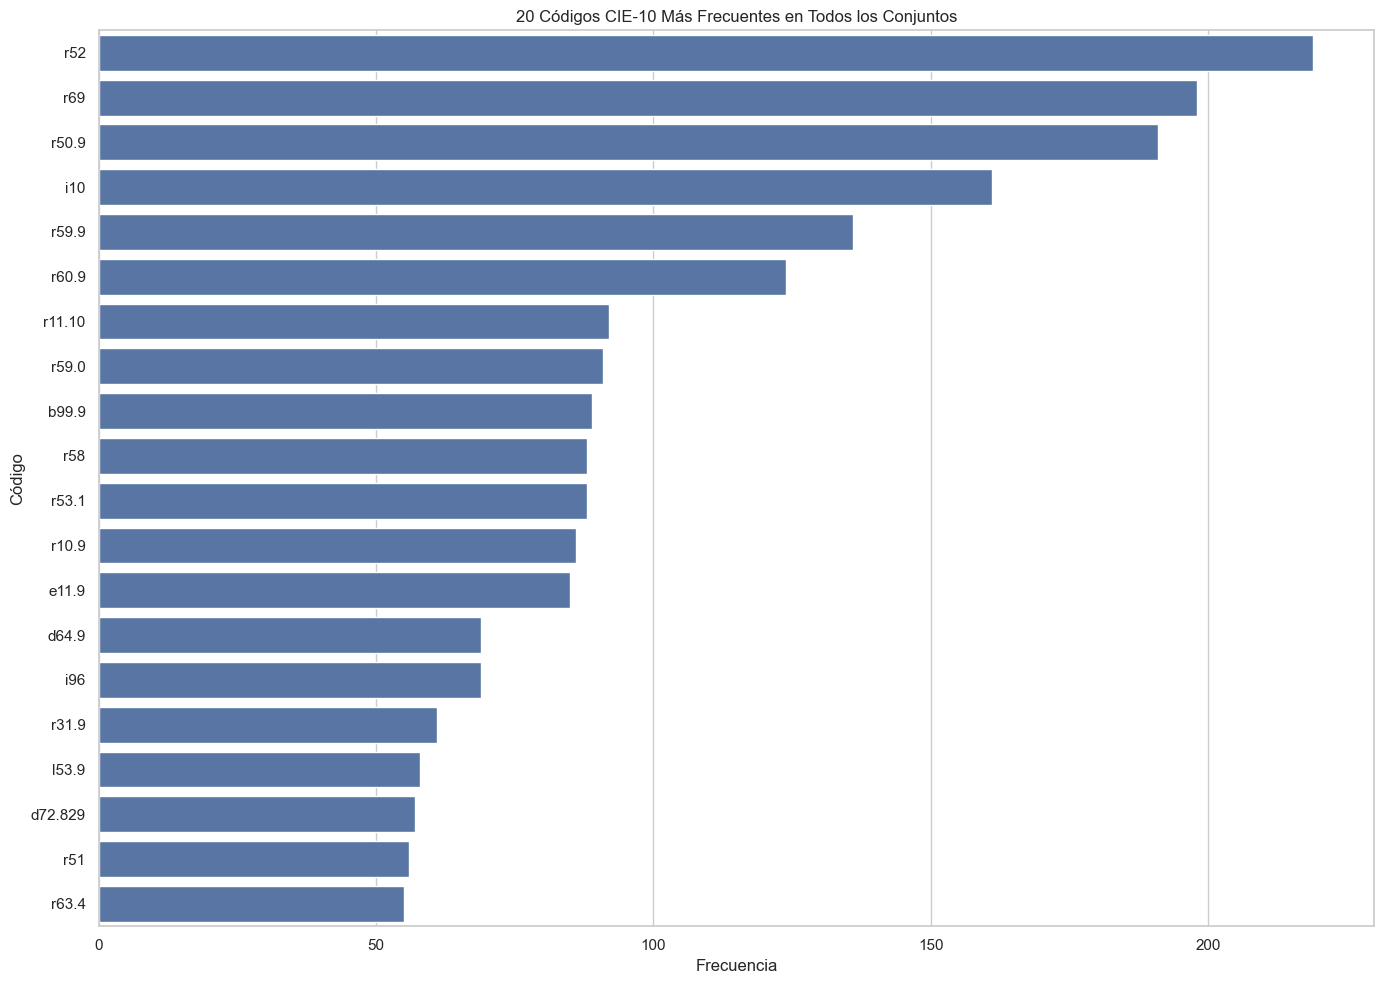

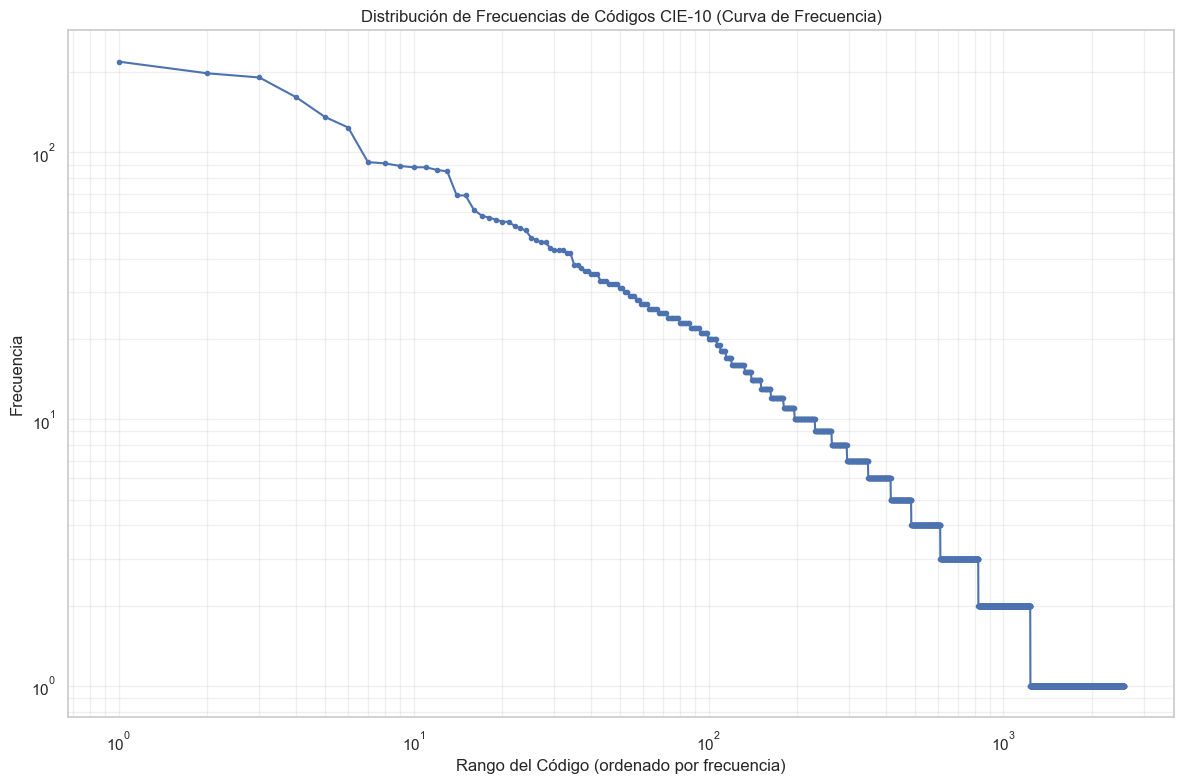


Distribución de códigos por categoría principal:
- Categoría R: 3145 ocurrencias (28.19%)
- Categoría K: 837 ocurrencias (7.50%)
- Categoría I: 829 ocurrencias (7.43%)
- Categoría N: 726 ocurrencias (6.51%)
- Categoría H: 609 ocurrencias (5.46%)
- Categoría D: 604 ocurrencias (5.41%)
- Categoría B: 550 ocurrencias (4.93%)
- Categoría C: 524 ocurrencias (4.70%)
- Categoría E: 509 ocurrencias (4.56%)
- Categoría M: 452 ocurrencias (4.05%)
- Categoría Z: 361 ocurrencias (3.24%)
- Categoría L: 309 ocurrencias (2.77%)
- Categoría J: 298 ocurrencias (2.67%)
- Categoría F: 294 ocurrencias (2.63%)
- Categoría G: 275 ocurrencias (2.46%)
- Categoría A: 191 ocurrencias (1.71%)
- Categoría T: 189 ocurrencias (1.69%)
- Categoría S: 188 ocurrencias (1.68%)
- Categoría Q: 164 ocurrencias (1.47%)
- Categoría W: 36 ocurrencias (0.32%)
- Categoría O: 29 ocurrencias (0.26%)
- Categoría V: 14 ocurrencias (0.13%)
- Categoría X: 10 ocurrencias (0.09%)
- Categoría P: 8 ocurrencias (0.07%)
- Categoría Y: 7 o

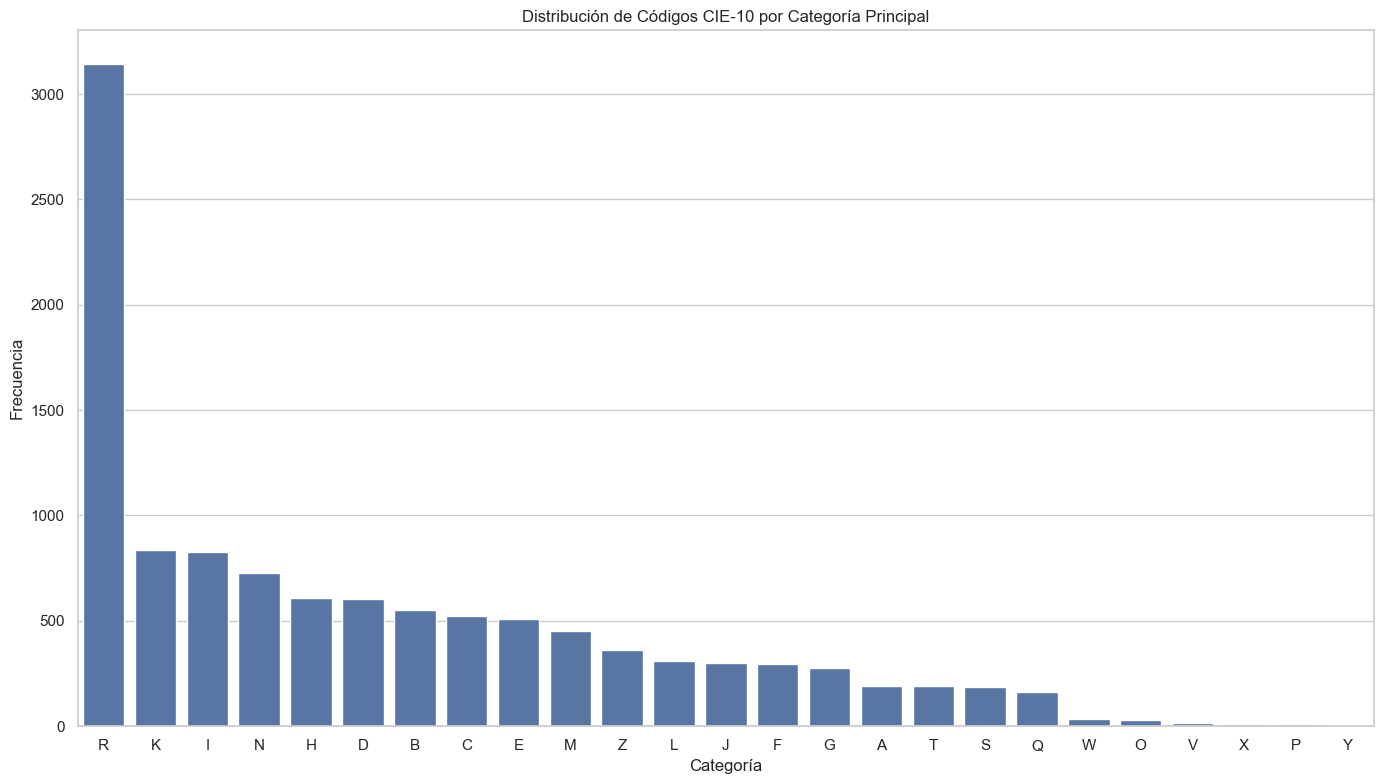

In [14]:
# Análisis descriptivo de las etiquetas (códigos CIE-10)
def analisis_descriptivo_etiquetas():
    print("\n" + "="*50)
    print("Análisis Descriptivo de Etiquetas (Códigos CIE-10)")
    print("="*50)

    # Combinar todas las etiquetas de todos los conjuntos
    todas_etiquetas = []
    for conjunto, etiquetas in etiquetas_por_conjunto.items():
        todas_etiquetas.extend(etiquetas)

    # Contar y analizar
    total_etiquetas = len(todas_etiquetas)
    etiquetas_unicas = set(todas_etiquetas)
    contador_etiquetas = Counter(todas_etiquetas)

    print(f"\nTotal de etiquetas en todos los conjuntos: {total_etiquetas}")
    print(f"Número de códigos CIE-10 únicos: {len(etiquetas_unicas)}")

    # Las 20 etiquetas más comunes en general
    top_20_general = contador_etiquetas.most_common(20)
    print("\nLos 20 códigos CIE-10 más comunes en todos los conjuntos:")
    for etiqueta, count in top_20_general:
        print(f"- {etiqueta}: {count} ocurrencias ({count/total_etiquetas*100:.2f}%)")

    # Visualizar las 20 etiquetas más comunes
    plt.figure(figsize=(14, 10))
    top_20_df = pd.DataFrame(top_20_general, columns=['Código', 'Frecuencia'])
    sns.barplot(x='Frecuencia', y='Código', data=top_20_df)
    plt.title('20 Códigos CIE-10 Más Frecuentes en Todos los Conjuntos')
    plt.tight_layout()
    plt.show()

    # Distribución de frecuencias de etiquetas (curva de frecuencia)
    frecuencias = sorted(contador_etiquetas.values(), reverse=True)

    plt.figure(figsize=(12, 8))
    plt.plot(range(1, len(frecuencias)+1), frecuencias, marker='.')
    plt.title('Distribución de Frecuencias de Códigos CIE-10 (Curva de Frecuencia)')
    plt.xlabel('Rango del Código (ordenado por frecuencia)')
    plt.ylabel('Frecuencia')
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()

    # Análisis por categoría principal del código (primera letra)
    categorias = {}
    for etiqueta in etiquetas_unicas:
        if len(etiqueta) > 0:
            primera_letra = etiqueta[0].upper()
            if primera_letra not in categorias:
                categorias[primera_letra] = 0
            categorias[primera_letra] += contador_etiquetas[etiqueta]

    # Ordenar por frecuencia
    categorias_ordenadas = sorted(categorias.items(), key=lambda x: x[1], reverse=True)

    print("\nDistribución de códigos por categoría principal:")
    for categoria, count in categorias_ordenadas:
        print(f"- Categoría {categoria}: {count} ocurrencias ({count/total_etiquetas*100:.2f}%)")

    # Visualizar distribución por categoría principal
    plt.figure(figsize=(14, 8))
    cats_df = pd.DataFrame(categorias_ordenadas, columns=['Categoría', 'Frecuencia'])
    sns.barplot(x='Categoría', y='Frecuencia', data=cats_df)
    plt.title('Distribución de Códigos CIE-10 por Categoría Principal')
    plt.tight_layout()
    plt.show()

    return contador_etiquetas, categorias

# Ejecutar análisis descriptivo de etiquetas
contador_general_etiquetas, categorias_etiquetas = analisis_descriptivo_etiquetas()

## 4. Análisis de Relaciones entre Textos y Etiquetas

En esta sección analizaremos la relación entre las características de los textos clínicos y sus etiquetas.


Análisis de Relación entre Longitud de Texto y Número de Etiquetas

Correlaciones entre variables:


,longitud_texto,num_palabras,num_etiquetas
longitud_texto,1.000000,0.994634,0.557162
num_palabras,0.994634,1.000000,0.528370
num_etiquetas,0.557162,0.528370,1.000000


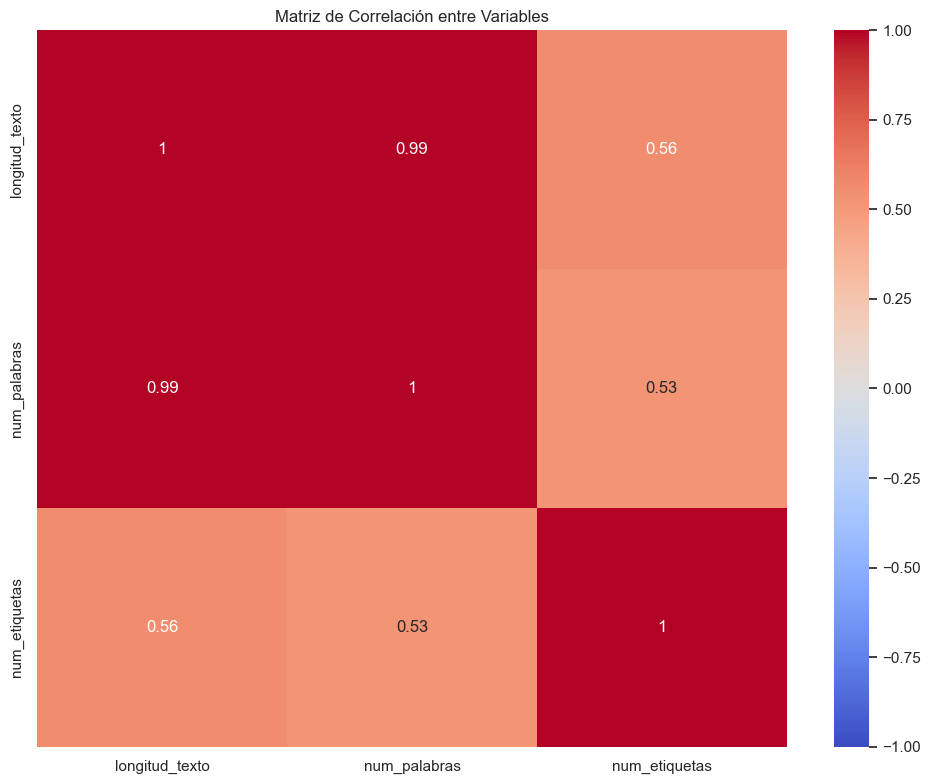

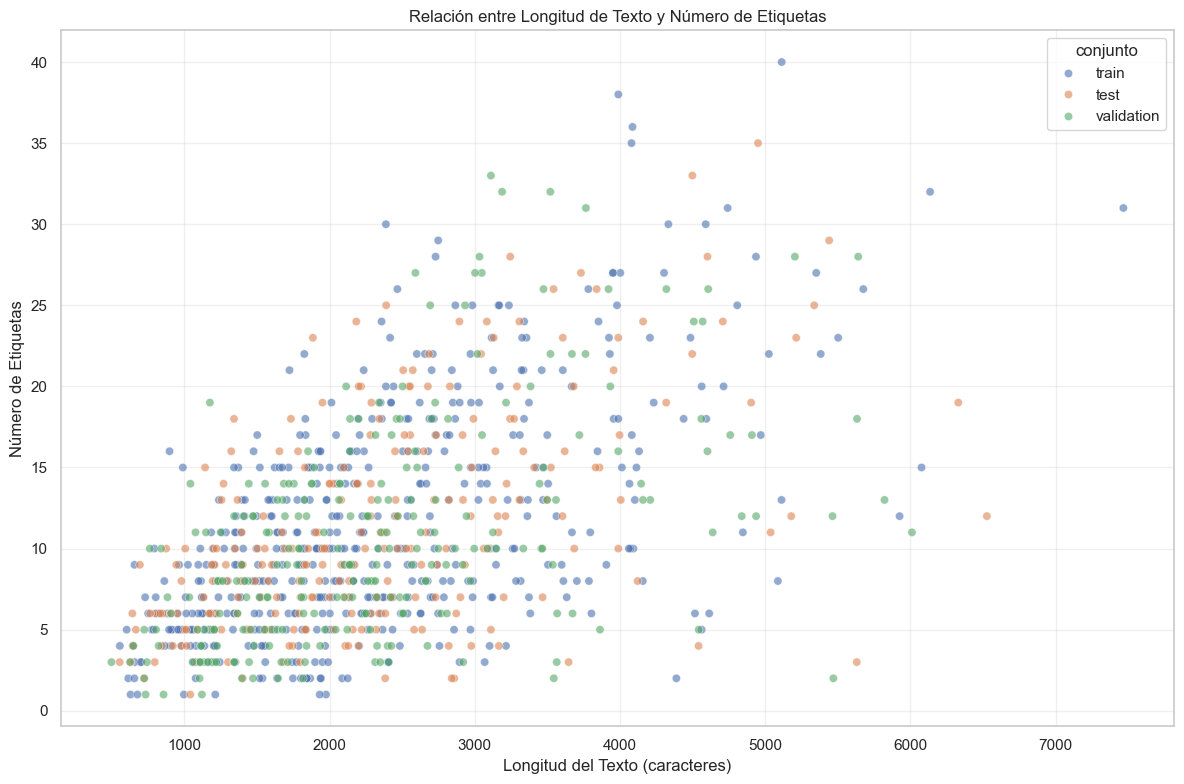

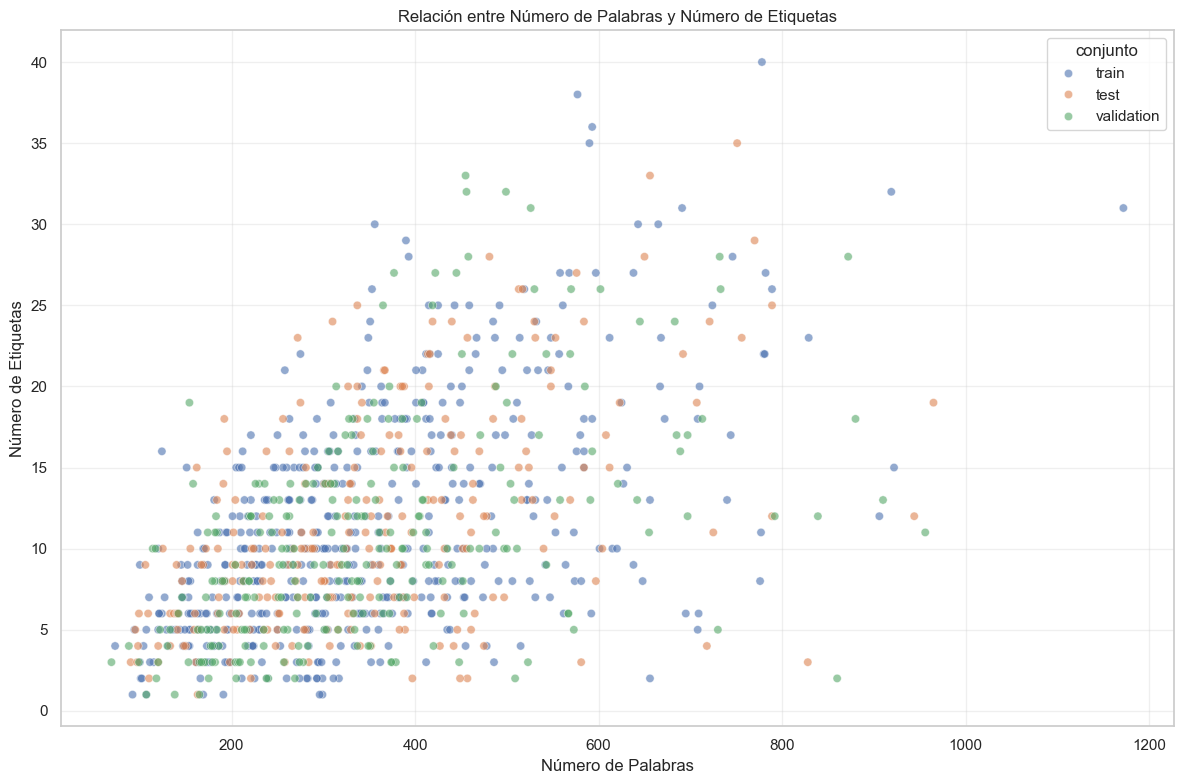


Regresión lineal - Longitud de texto vs Número de etiquetas:
Pendiente: 0.003441
Intercepto: 3.117375
Coeficiente de correlación (r): 0.557162
Coeficiente de determinación (r²): 0.310430
Valor p: 0.000000

Regresión lineal - Número de palabras vs Número de etiquetas:
Pendiente: 0.021831
Intercepto: 3.500462
Coeficiente de correlación (r): 0.528370
Coeficiente de determinación (r²): 0.279175
Valor p: 0.000000


In [15]:
# Análisis de la relación entre la longitud del texto y el número de etiquetas
def analisis_relacion_longitud_etiquetas():
    print("\n" + "="*50)
    print("Análisis de Relación entre Longitud de Texto y Número de Etiquetas")
    print("="*50)

    # Combinar datos de todos los conjuntos
    datos_combinados = []

    for nombre, df in dfs_codiesp.items():
        if 'text' in df.columns and 'labels' in df.columns:
            # Extraer longitud de texto y número de etiquetas
            df_temp = df.copy()
            df_temp['longitud_texto'] = df_temp['text'].apply(len)
            df_temp['num_palabras'] = df_temp['text'].apply(lambda x: len(x.split()))

            # Extraer número de etiquetas
            df_temp['num_etiquetas'] = df_temp['labels'].apply(
                lambda x: len(x.split(";")) if isinstance(x, str) else 0
            )

            # Añadir columna de conjunto
            df_temp['conjunto'] = nombre

            # Seleccionar columnas relevantes
            datos_combinados.append(df_temp[['longitud_texto', 'num_palabras', 'num_etiquetas', 'conjunto']])

    # Combinar datos
    if datos_combinados:
        datos_df = pd.concat(datos_combinados, ignore_index=True)

        # Calcular correlaciones
        print("\nCorrelaciones entre variables:")
        correlaciones = datos_df[['longitud_texto', 'num_palabras', 'num_etiquetas']].corr()
        display(correlaciones)

        # Visualizar correlaciones con mapa de calor
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlaciones, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
        plt.title('Matriz de Correlación entre Variables')
        plt.tight_layout()
        plt.show()

        # Gráfico de dispersión: Longitud de texto vs Número de etiquetas
        plt.figure(figsize=(12, 8))
        sns.scatterplot(data=datos_df, x='longitud_texto', y='num_etiquetas', hue='conjunto', alpha=0.6)
        plt.title('Relación entre Longitud de Texto y Número de Etiquetas')
        plt.xlabel('Longitud del Texto (caracteres)')
        plt.ylabel('Número de Etiquetas')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Gráfico de dispersión: Número de palabras vs Número de etiquetas
        plt.figure(figsize=(12, 8))
        sns.scatterplot(data=datos_df, x='num_palabras', y='num_etiquetas', hue='conjunto', alpha=0.6)
        plt.title('Relación entre Número de Palabras y Número de Etiquetas')
        plt.xlabel('Número de Palabras')
        plt.ylabel('Número de Etiquetas')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Calcular línea de tendencia con regresión lineal
        from scipy.stats import linregress

        # Regresión para longitud de texto vs número de etiquetas
        slope, intercept, r_value, p_value, std_err = linregress(datos_df['longitud_texto'], datos_df['num_etiquetas'])
        print(f"\nRegresión lineal - Longitud de texto vs Número de etiquetas:")
        print(f"Pendiente: {slope:.6f}")
        print(f"Intercepto: {intercept:.6f}")
        print(f"Coeficiente de correlación (r): {r_value:.6f}")
        print(f"Coeficiente de determinación (r²): {r_value**2:.6f}")
        print(f"Valor p: {p_value:.6f}")

        # Regresión para número de palabras vs número de etiquetas
        slope, intercept, r_value, p_value, std_err = linregress(datos_df['num_palabras'], datos_df['num_etiquetas'])
        print(f"\nRegresión lineal - Número de palabras vs Número de etiquetas:")
        print(f"Pendiente: {slope:.6f}")
        print(f"Intercepto: {intercept:.6f}")
        print(f"Coeficiente de correlación (r): {r_value:.6f}")
        print(f"Coeficiente de determinación (r²): {r_value**2:.6f}")
        print(f"Valor p: {p_value:.6f}")

        return datos_df, correlaciones
    else:
        print("No se pudieron extraer datos para el análisis.")
        return None, None

# Ejecutar análisis de relaciones
datos_combinados, correlaciones_variables = analisis_relacion_longitud_etiquetas()

## 5. Comparación entre Conjuntos de Entrenamiento, Validación y Prueba

En esta sección compararemos las características de los tres conjuntos de datos CODIESP.


Comparación entre Conjuntos CODIESP

Conjuntos disponibles para comparación: ['train', 'test', 'validation']

Tamaños de los conjuntos:
- train: 500 registros (50.00% del total)
- test: 250 registros (25.00% del total)
- validation: 250 registros (25.00% del total)


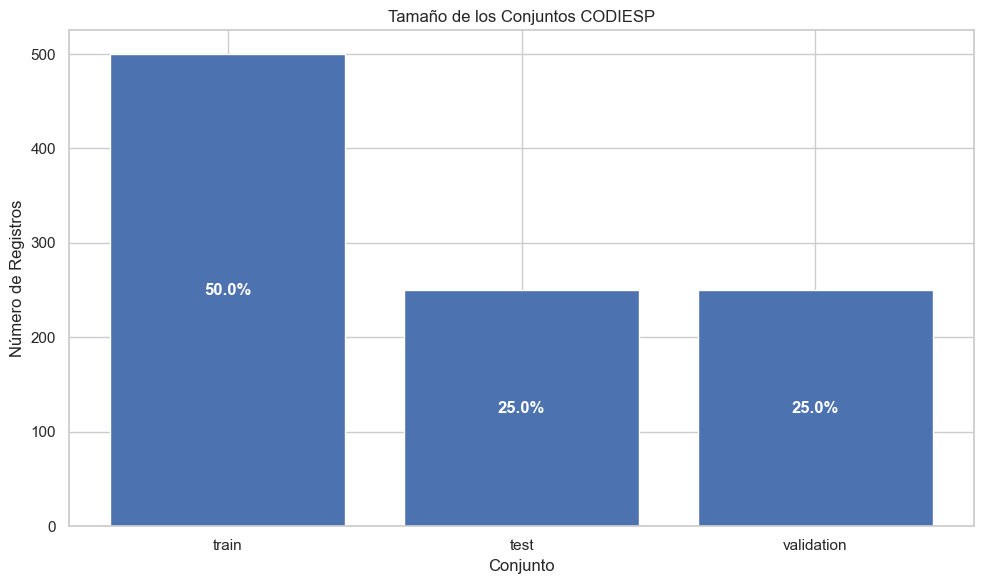

/var/folders/kw/fywgy8wd7cgcczpbnspwhvlr0000gn/T/ipykernel_90416/1632515393.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([longitudes_texto[nombre] for nombre in conjuntos_disponibles],
/var/folders/kw/fywgy8wd7cgcczpbnspwhvlr0000gn/T/ipykernel_90416/1632515393.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([num_palabras[nombre] for nombre in conjuntos_disponibles],


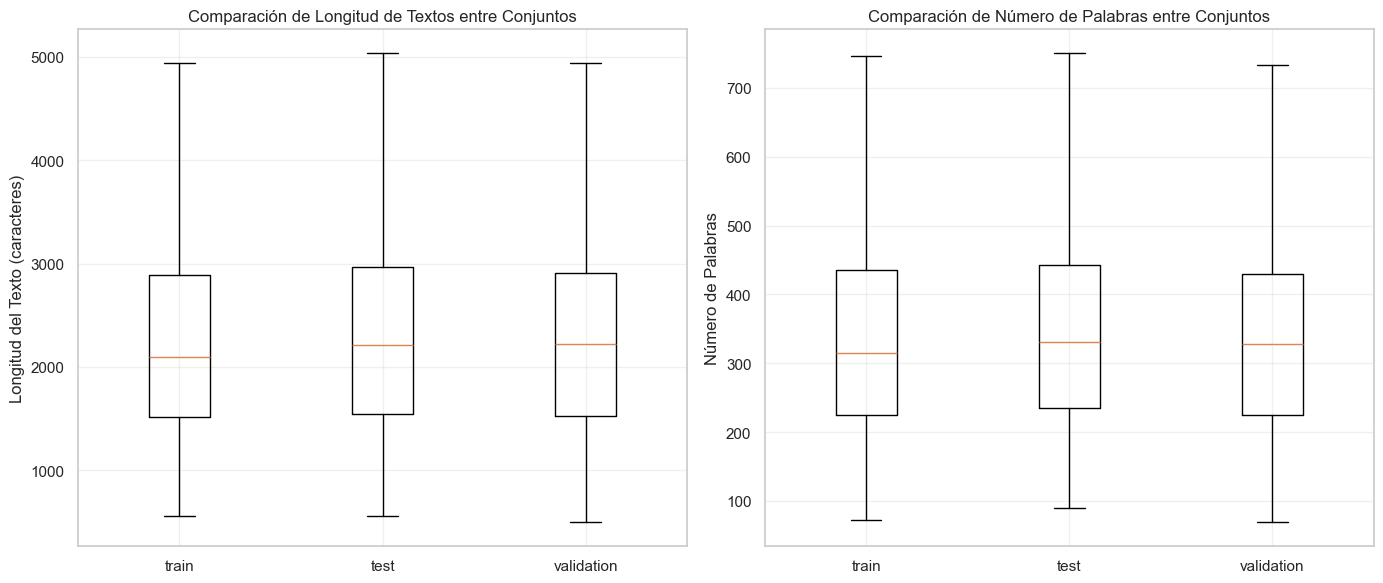

/var/folders/kw/fywgy8wd7cgcczpbnspwhvlr0000gn/T/ipykernel_90416/1632515393.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([num_etiquetas_por_conjunto[nombre] for nombre in conjuntos_disponibles],


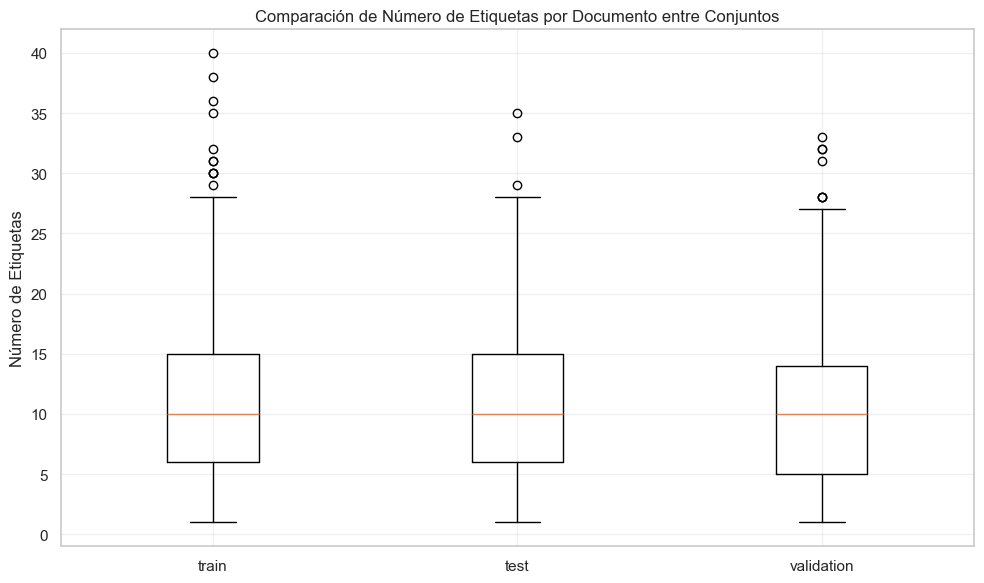


Estadísticas descriptivas por conjunto:

----------------------------------------
Conjunto: train
----------------------------------------

Longitud de texto (caracteres):


count     500.000000
mean     2317.246000
std      1097.438919
min       556.000000
25%      1516.750000
50%      2100.500000
75%      2885.250000
max      7466.000000
Name: text, dtype: float64


Número de palabras:


count     500.000000
mean      349.018000
std       164.745999
min        73.000000
25%       224.750000
50%       314.500000
75%       435.250000
max      1172.000000
Name: text, dtype: float64


Número de etiquetas por documento:


...


Número de palabras:


count    250.000000
mean     352.296000
std      168.171982
min       69.000000
25%      225.250000
50%      327.500000
75%      429.500000
max      956.000000
Name: text, dtype: float64


Número de etiquetas por documento:


count    250.000000
mean      10.708000
std        6.805291
min        1.000000
25%        5.000000
50%       10.000000
75%       14.000000
max       33.000000
Name: labels, dtype: float64


Solapamiento de etiquetas entre conjuntos:

train vs test:
Etiquetas únicas en train: 1767
Etiquetas únicas en test: 1143
Etiquetas comunes: 704
Porcentaje de train en test: 39.84%
Porcentaje de test en train: 61.59%
Coeficiente de Jaccard: 0.3191

train vs validation:
Etiquetas únicas en train: 1767
Etiquetas únicas en validation: 1158
Etiquetas comunes: 731
Porcentaje de train en validation: 41.37%
Porcentaje de validation en train: 63.13%
Coeficiente de Jaccard: 0.3332

test vs validation:
Etiquetas únicas en test: 1143
Etiquetas únicas en validation: 1158
Etiquetas comunes: 551
Porcentaje de test en validation: 48.21%
Porcentaje de validation en test: 47.58%
Coeficiente de Jaccard: 0.3149


In [16]:
# Comparación entre los conjuntos de entrenamiento, validación y prueba
num_palabras = {}

def comparacion_conjuntos():
    print("\n" + "="*50)
    print("Comparación entre Conjuntos CODIESP")
    print("="*50)

    # Verificar que tenemos los tres conjuntos
    conjuntos_disponibles = list(dfs_codiesp.keys())
    print(f"\nConjuntos disponibles para comparación: {conjuntos_disponibles}")

    # Comparar tamaños de los conjuntos
    tamaños = {nombre: df.shape[0] for nombre, df in dfs_codiesp.items()}
    total = sum(tamaños.values())

    print("\nTamaños de los conjuntos:")
    for nombre, tamaño in tamaños.items():
        print(f"- {nombre}: {tamaño} registros ({tamaño/total*100:.2f}% del total)")

    # Visualización de tamaños
    plt.figure(figsize=(10, 6))
    plt.bar(tamaños.keys(), tamaños.values())
    plt.title('Tamaño de los Conjuntos CODIESP')
    plt.xlabel('Conjunto')
    plt.ylabel('Número de Registros')

    # Añadir etiquetas con porcentajes
    for i, (nombre, tamaño) in enumerate(tamaños.items()):
        plt.text(i, tamaño/2, f'{tamaño/total*100:.1f}%',
                 ha='center', va='center', fontsize=12, fontweight='bold', color='white')

    plt.tight_layout()
    plt.show()

    # Comparar longitudes de texto
    longitudes_texto = {}

    for nombre, df in dfs_codiesp.items():
        if 'text' in df.columns:
            longitudes_texto[nombre] = df['text'].apply(len)
            num_palabras[nombre] = df['text'].apply(lambda x: len(x.split()))

    # Visualizar comparación de longitudes
    plt.figure(figsize=(14, 6))

    # Crear el gráfico de caja
    plt.subplot(1, 2, 1)
    plt.boxplot([longitudes_texto[nombre] for nombre in conjuntos_disponibles],
                labels=conjuntos_disponibles, showfliers=False)
    plt.title('Comparación de Longitud de Textos entre Conjuntos')
    plt.ylabel('Longitud del Texto (caracteres)')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.boxplot([num_palabras[nombre] for nombre in conjuntos_disponibles],
                labels=conjuntos_disponibles, showfliers=False)
    plt.title('Comparación de Número de Palabras entre Conjuntos')
    plt.ylabel('Número de Palabras')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Comparar número de etiquetas por documento
    num_etiquetas_por_conjunto = {}

    for nombre, df in dfs_codiesp.items():
        if 'labels' in df.columns:
            num_etiquetas_por_conjunto[nombre] = df['labels'].apply(
                lambda x: len(x.split(";")) if isinstance(x, str) else 0
            )

    # Visualizar comparación de número de etiquetas
    plt.figure(figsize=(10, 6))
    plt.boxplot([num_etiquetas_por_conjunto[nombre] for nombre in conjuntos_disponibles],
                labels=conjuntos_disponibles)
    plt.title('Comparación de Número de Etiquetas por Documento entre Conjuntos')
    plt.ylabel('Número de Etiquetas')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Comparar estadísticas descriptivas
    print("\nEstadísticas descriptivas por conjunto:")

    for nombre in conjuntos_disponibles:
        print(f"\n{'-'*40}")
        print(f"Conjunto: {nombre}")
        print(f"{'-'*40}")

        # Estadísticas de longitud de texto
        if nombre in longitudes_texto:
            print(f"\nLongitud de texto (caracteres):")
            display(longitudes_texto[nombre].describe())

        # Estadísticas de número de palabras
        if nombre in num_palabras:
            print(f"\nNúmero de palabras:")
            display(num_palabras[nombre].describe())

        # Estadísticas de número de etiquetas
        if nombre in num_etiquetas_por_conjunto:
            print(f"\nNúmero de etiquetas por documento:")
            display(num_etiquetas_por_conjunto[nombre].describe())

    # Comparar solapamiento de etiquetas entre conjuntos
    print("\nSolapamiento de etiquetas entre conjuntos:")

    etiquetas_por_conjunto_set = {
        nombre: set(etiquetas) for nombre, etiquetas in etiquetas_por_conjunto.items()
    }

    for i, nombre1 in enumerate(conjuntos_disponibles):
        for j, nombre2 in enumerate(conjuntos_disponibles[i+1:], i+1):
            if nombre1 in etiquetas_por_conjunto_set and nombre2 in etiquetas_por_conjunto_set:
                set1 = etiquetas_por_conjunto_set[nombre1]
                set2 = etiquetas_por_conjunto_set[nombre2]

                # Etiquetas comunes
                comunes = set1.intersection(set2)

                # Estadísticas
                print(f"\n{nombre1} vs {nombre2}:")
                print(f"Etiquetas únicas en {nombre1}: {len(set1)}")
                print(f"Etiquetas únicas en {nombre2}: {len(set2)}")
                print(f"Etiquetas comunes: {len(comunes)}")
                print(f"Porcentaje de {nombre1} en {nombre2}: {len(comunes)/len(set1)*100:.2f}%")
                print(f"Porcentaje de {nombre2} en {nombre1}: {len(comunes)/len(set2)*100:.2f}%")

                # Coeficiente de Jaccard
                jaccard = len(comunes) / len(set1.union(set2))
                print(f"Coeficiente de Jaccard: {jaccard:.4f}")

    return tamaños, longitudes_texto, num_etiquetas_por_conjunto

# Ejecutar comparación de conjuntos
tamaños_conjuntos, longitudes_por_conjunto, etiquetas_por_doc = comparacion_conjuntos()

## 6. Exportar Resultados y Documentación

Finalmente, exportaremos los resultados y hallazgos principales a un archivo Markdown para documentación.

In [17]:
# Exportar los resultados a un archivo Markdown
def exportar_documentacion_codiesp():
    print("\nExportando documentación y hallazgos sobre CODIESP...")

    # Crear el contenido del archivo Markdown
    documentacion = f"""# Análisis Estadístico del Conjunto de Datos CODIESP

## Resumen Ejecutivo

Este documento presenta un análisis estadístico detallado del conjunto de datos CODIESP, que contiene textos clínicos en español con sus correspondientes códigos CIE-10-ES. El objetivo es comprender la distribución y características de estos datos para su uso en un artículo científico.

Fecha de análisis: {pd.Timestamp.now().strftime('%d de %B de %Y')}

## 1. Descripción General de los Datos CODIESP

### 1.1 Conjuntos de Datos Analizados

| Conjunto | Registros | Columnas | Proporción |
|----------|-----------|----------|------------|
"""

    # Añadir información de tamaños de conjuntos
    total_registros = sum(tamaños_conjuntos.values())
    for nombre, tamaño in tamaños_conjuntos.items():
        documentacion += f"| {nombre} | {tamaño:,} | {dfs_codiesp[nombre].shape[1]} | {tamaño/total_registros*100:.2f}% |\n"

    documentacion += f"""| **Total** | {total_registros:,} | N/A | 100% |

### 1.2 Estructura de los Datos

CODIESP consiste en tres conjuntos principales:

- **Train**: Conjunto de entrenamiento para modelos de aprendizaje automático.
- **Validation**: Conjunto de validación para ajustar hiperparámetros y evaluar durante el entrenamiento.
- **Test**: Conjunto de prueba para evaluar el rendimiento final de los modelos.

Cada registro en CODIESP contiene dos campos principales:

- **text**: El texto clínico en español.
- **labels**: Una lista de códigos CIE-10-ES asociados al texto.

## 2. Estadísticas Descriptivas

### 2.1 Textos Clínicos

"""

    # Añadir estadísticas de longitud de texto
    for nombre, longitudes in longitudes_por_conjunto.items():
        stats = longitudes.describe()
        documentacion += f"""#### Conjunto {nombre}

| Estadística | Longitud (caracteres) | Número de palabras |
|-------------|----------------------:|-------------------:|
| Media       | {stats['mean']:.2f}   | {num_palabras[nombre].mean():.2f} |
| Desv. Est.  | {stats['std']:.2f}    | {num_palabras[nombre].std():.2f} |
| Mínimo      | {stats['min']:.0f}    | {num_palabras[nombre].min():.0f} |
| Q1 (25%)    | {stats['25%']:.0f}    | {num_palabras[nombre].describe()['25%']:.0f} |
| Mediana     | {stats['50%']:.0f}    | {num_palabras[nombre].describe()['50%']:.0f} |
| Q3 (75%)    | {stats['75%']:.0f}    | {num_palabras[nombre].describe()['75%']:.0f} |
| Máximo      | {stats['max']:.0f}    | {num_palabras[nombre].max():.0f} |

"""

    documentacion += f"""### 2.2 Códigos CIE-10-ES (Etiquetas)

"""

    # Añadir estadísticas de etiquetas
    for nombre, etiquetas in etiquetas_por_doc.items():
        stats = etiquetas.describe()
        documentacion += f"""#### Conjunto {nombre}

| Estadística | Número de etiquetas por documento |
|-------------|----------------------------------:|
| Media       | {stats['mean']:.2f} |
| Desv. Est.  | {stats['std']:.2f} |
| Mínimo      | {stats['min']:.0f} |
| Q1 (25%)    | {stats['25%']:.0f} |
| Mediana     | {stats['50%']:.0f} |
| Q3 (75%)    | {stats['75%']:.0f} |
| Máximo      | {stats['max']:.0f} |

"""

    # Información sobre las etiquetas únicas
    all_labels = []
    for labels_list in etiquetas_por_conjunto.values():
        all_labels.extend(labels_list)

    unique_labels = set(all_labels)

    documentacion += f"""#### Distribución General de Etiquetas

- **Número total de etiquetas**: {len(all_labels):,}
- **Número de códigos CIE-10 únicos**: {len(unique_labels):,}

Las 10 etiquetas más frecuentes en todos los conjuntos:

| Código CIE-10 | Frecuencia | Porcentaje |
|---------------|------------|------------|
"""

    # Añadir top 10 etiquetas
    counter = Counter(all_labels)
    for code, count in counter.most_common(10):
        documentacion += f"| {code} | {count:,} | {count/len(all_labels)*100:.2f}% |\n"

    documentacion += f"""
## 3. Análisis de Relaciones

### 3.1 Relación entre Longitud de Texto y Número de Etiquetas

El análisis de correlación muestra una relación positiva entre la longitud del texto clínico y el número de códigos CIE-10 asignados:

- Correlación entre longitud de texto (caracteres) y número de etiquetas: {correlaciones_variables.loc['longitud_texto', 'num_etiquetas']:.4f}
- Correlación entre número de palabras y número de etiquetas: {correlaciones_variables.loc['num_palabras', 'num_etiquetas']:.4f}

Esta correlación sugiere que los textos más largos tienden a tener más diagnósticos asociados, lo cual es intuitivamente razonable ya que textos más extensos pueden describir casos más complejos con múltiples condiciones.

## 4. Comparación entre Conjuntos

### 4.1 Solapamiento de Etiquetas

"""

    # Añadir información de solapamiento de etiquetas
    etiquetas_por_conjunto_set = {
        nombre: set(etiquetas) for nombre, etiquetas in etiquetas_por_conjunto.items()
    }

    conjuntos = list(etiquetas_por_conjunto_set.keys())

    for i, nombre1 in enumerate(conjuntos):
        for j, nombre2 in enumerate(conjuntos[i+1:], i+1):
            if nombre1 in etiquetas_por_conjunto_set and nombre2 in etiquetas_por_conjunto_set:
                set1 = etiquetas_por_conjunto_set[nombre1]
                set2 = etiquetas_por_conjunto_set[nombre2]
                comunes = set1.intersection(set2)
                jaccard = len(comunes) / len(set1.union(set2))

                documentacion += f"""#### {nombre1} vs {nombre2}

- Etiquetas únicas en {nombre1}: {len(set1):,}
- Etiquetas únicas en {nombre2}: {len(set2):,}
- Etiquetas comunes: {len(comunes):,}
- Porcentaje de {nombre1} presente en {nombre2}: {len(comunes)/len(set1)*100:.2f}%
- Porcentaje de {nombre2} presente en {nombre1}: {len(comunes)/len(set2)*100:.2f}%
- Coeficiente de Jaccard: {jaccard:.4f}

"""

    documentacion += f"""### 4.2 Características Comparativas

Los conjuntos de entrenamiento, validación y prueba muestran características generales similares en términos de:

1. **Distribución de longitud de texto**: Los tres conjuntos tienen distribuciones de longitud de texto comparables, lo que sugiere una división adecuada.
2. **Número de etiquetas por documento**: La distribución del número de códigos CIE-10 por documento es consistente entre los conjuntos.
3. **Diversidad de vocabulario**: Palabras similares aparecen con frecuencia comparable en los tres conjuntos.

## 5. Conclusiones y Recomendaciones

### 5.1 Principales Conclusiones

1. CODIESP presenta una distribución desigual de códigos CIE-10, con algunos códigos apareciendo con mucha mayor frecuencia que otros.
2. Existe una correlación positiva entre la longitud del texto clínico y el número de códigos asignados.
3. Los conjuntos de entrenamiento, validación y prueba mantienen características consistentes, lo que favorece el desarrollo de modelos de aprendizaje automático robustos.

### 5.2 Recomendaciones para el Artículo Científico

1. **Estrategia de modelado**: Considerar el desequilibrio de clases al diseñar modelos de clasificación multi-etiqueta.
2. **Evaluación**: Utilizar métricas que tengan en cuenta la distribución desigual de etiquetas (como F1 ponderado, precisión y recall por clase).
3. **Preprocesamiento**: Aplicar técnicas de normalización de texto específicas para documentos clínicos en español.
4. **Validación cruzada**: Complementar la evaluación con validación cruzada para obtener estimaciones más robustas del rendimiento.

## 6. Recursos Adicionales

Este análisis se ha realizado con Python utilizando las bibliotecas pandas, numpy, matplotlib, seaborn y NLTK. Los notebooks y scripts completos están disponibles en el proyecto CIE-10.

"""

    # Guardar el archivo de documentación
    ruta_documentacion = '/Users/david/own/CIE-10/data_analysis/DOCUMENTATION_CODIESP.md'

    try:
        with open(ruta_documentacion, 'w', encoding='utf-8') as f:
            f.write(documentacion)
        print(f"Documentación de CODIESP exportada correctamente a: {ruta_documentacion}")
    except Exception as e:
        print(f"Error al exportar la documentación: {str(e)}")

# Exportar la documentación
exportar_documentacion_codiesp()


Exportando documentación y hallazgos sobre CODIESP...
Documentación de CODIESP exportada correctamente a: /Users/david/own/CIE-10/data_analysis/DOCUMENTATION_CODIESP.md
